In [1]:
# --- Colab setup (auto-inserted; no-op outside Colab). tag: colab-bootstrap ---
import sys
if "google.colab" in sys.modules:
    import os, subprocess, pathlib
    _slug = "aniryou/full-stack-agentic-engineer"
    _root = pathlib.Path("/content") / "full-stack-agentic-engineer"
    if not _root.exists():
        subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{_slug}.git", str(_root)], check=True)
    os.chdir(_root / "04-inference-engine/kv-cache")
    for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_c / "pyproject.toml").exists() or (_c / "setup.py").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(_c)]); break
        if (_c / "requirements.txt").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_c / "requirements.txt")]); break
        if _c == _root:
            break
    if str(pathlib.Path.cwd()) not in sys.path:
        sys.path.insert(0, str(pathlib.Path.cwd()))


# KV Cache from Scratch — Worked Notebook

**Tier: T0.** numpy and matplotlib only, on a laptop or a Colab CPU runtime (both are preinstalled there); no
GPU and no PyTorch. It uses [`kernel-core`](../kernel-core/README.md) (`kerncore.kv`) for the random weights, a
reference copy of the model with cost counters, and the cache-size formula; the code that matters — attention with
a cache and the two generation loops — is written out here. Sizes are printed in binary units (KiB, GiB) with
decimal GB in brackets, as in the [primer](kv-cache-primer.md). The whole notebook runs in well under a minute on a
CPU; the saved outputs are from such a run. PyTorch is optional: the last cell repeats one check in torch when it
is installed and skips itself when it is not.

A runnable companion to the primer. Four ideas, in order:

1. **Attention re-reads all past K and V** every step — so cache them once.
2. **Cached generation gives *identical* output** to recomputing — same result, far less work.
3. **Per-token cost:** naive grows with the prefix, cached grows only with the cache — slowly.
4. **The cache is big** and lives in GPU memory — this is what bounds serving.

Random weights, so the generated tokens are gibberish — that's fine, because the test is whether two code paths
*agree*, not whether text is good.

> Notebook 02 is the fill-in-the-blank version. This one is also its answer key.

In [2]:
# numpy + matplotlib (both preinstalled on Colab); no GPU, no torch. The next lines make `import kerncore`
# work from a checkout without installing anything: kernel-core sits next to this folder.
import os, sys, pathlib, math, time
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")   # tiny matrices: one BLAS thread is faster, and steady
os.environ.setdefault("OMP_NUM_THREADS", "1")        # on a shared CPU (set before numpy is imported)
_core = pathlib.Path.cwd().resolve().parent / "kernel-core"
if (_core / "kerncore").is_dir() and str(_core) not in sys.path:
    sys.path.insert(0, str(_core))
import numpy as np
import matplotlib.pyplot as plt
from kerncore import kv            # random weights, a reference copy of the model, the size formulas

rng = np.random.default_rng(0)
print("numpy + kerncore ready")

numpy + kerncore ready


## 1. Attention, with an optional cache

`forward` takes an optional `cache = (past_k, past_v)`. If given, it concatenates the
new token's K and V onto the past and returns the grown cache. Read the two commented
blocks — the concatenation, and the causal mask — that's the entire mechanism.

In [3]:
def softmax(x):
    x = x - x.max(axis=-1, keepdims=True)          # subtract the row max: exp never overflows
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)


class CausalSelfAttention:
    """One multi-head causal attention layer. K and V are what we will cache."""
    def __init__(self, p, n_heads):
        self.wq, self.wk, self.wv, self.wo = p["wq"], p["wk"], p["wv"], p["wo"]   # (C, C) each
        self.n_heads = n_heads
        self.head_dim = self.wq.shape[1] // n_heads

    def forward(self, x, cache=None):
        # x: (T, C).  During prefill T = prompt length; during decode T = 1.
        T, C = x.shape
        # (T, C) -> (n_heads, T, head_dim). The head_dim here sets cache size.
        split = lambda t: t.reshape(T, self.n_heads, self.head_dim).transpose(1, 0, 2)
        q, k, v = split(x @ self.wq), split(x @ self.wk), split(x @ self.wv)

        past_len = 0
        if cache is not None:                          # <-- THE CACHE, in two lines:
            past_k, past_v = cache                     #     glue the new token's K, V
            past_len = past_k.shape[1]                 #     onto everything we saw before,
            k = np.concatenate([past_k, k], axis=1)    #     concatenating along the
            v = np.concatenate([past_v, v], axis=1)    #     sequence (time) axis.
        new_cache = (k, v)                             # hand the grown cache back out

        # scores: each query dotted with every key -> (n_heads, T, past_len + T)
        att = q @ k.transpose(0, 2, 1) / math.sqrt(self.head_dim)

        # Causal mask by ABSOLUTE position. Query i sits at position past_len+i and
        # may look at key j only if j <= its own position. During decode the single
        # new query is at the end, so it legally sees the entire cache (no masking).
        q_pos = np.arange(past_len, past_len + T)[:, None]
        k_pos = np.arange(past_len + T)[None, :]
        att = np.where(k_pos > q_pos, -np.inf, att)
        att = softmax(att)

        y = (att @ v).transpose(1, 0, 2).reshape(T, C)
        return y @ self.wo, new_cache

## A tiny model

Embedding (token + position) → attention layers → output head. No MLP or LayerNorm, since neither touches the
cache. Each layer owns a cache, so caches are passed around as a **list**. The position embedding is looked up at
the *absolute* position `past_len + i`, the same position the causal mask uses — a decoder must know how much it
has already cached.

In [4]:
class MiniLM:
    """Token embedding + position embedding -> attention layers (with residuals) -> output head.
    No MLP, no norm on purpose: neither touches the KV cache, so leaving them out keeps every
    line about caching. Random weights -> gibberish tokens, but the two code paths must still
    produce the SAME gibberish, which is the whole point.
    Each layer keeps its own cache, so 'caches' is a list, one entry per layer."""
    def __init__(self, params):
        self.p = params
        self.layers = [CausalSelfAttention(lp, params["n_heads"]) for lp in params["layers"]]

    def forward(self, idx, caches=None):
        past_len = 0 if caches is None else caches[0][0].shape[1]
        x = self.p["emb"][idx] + self.p["pos"][past_len:past_len + len(idx)]   # token + absolute position
        new_caches = []
        for i, layer in enumerate(self.layers):
            layer_cache = None if caches is None else caches[i]
            y, c = layer.forward(x, layer_cache)
            x = x + y                                  # residual connection
            new_caches.append(c)
        return x @ self.p["head"], new_caches


# Random weights from kerncore, and a check that this model is the one kerncore tests.
params = kv.random_params(vocab=256, d_model=128, n_heads=4, n_layers=4, seed=0)
model = MiniLM(params)
_ids = rng.integers(0, 256, 10)
print("same logits as kerncore.kv.TinyDecoder:",
      np.allclose(model.forward(_ids)[0], kv.TinyDecoder(params).forward(_ids)[0], atol=1e-12))

same logits as kerncore.kv.TinyDecoder: True


## 2. Two ways to generate

**Naive** re-feeds the entire sequence every step. **Cached** feeds the prompt once
(*prefill*), then one token at a time (*decode*), carrying the cache forward.

The single difference that matters: cached decode calls `model.forward([next_id], caches)` with
**one** new token, not the whole history.

In [5]:
def generate_naive(model, prompt, n_new):
    """No cache: every step re-feeds the WHOLE sequence and recomputes all K, V."""
    idx, last_logits = list(prompt), []
    for _ in range(n_new):
        logits, _ = model.forward(np.array(idx))       # reprocess everything
        last_logits.append(logits[-1])
        idx.append(int(logits[-1].argmax()))            # greedy pick
    return np.array(idx), np.array(last_logits)

In [6]:
def generate_cached(model, prompt, n_new):
    """With cache: process the prompt once (prefill), then feed ONE token per step."""
    logits, caches = model.forward(np.array(prompt))            # PREFILL: prompt, no cache
    last_logits = [logits[-1]]
    idx = list(prompt) + [int(logits[-1].argmax())]
    for _ in range(n_new - 1):
        logits, caches = model.forward(np.array([idx[-1]]), caches)   # DECODE: 1 token + cache
        last_logits.append(logits[-1])
        idx.append(int(logits[-1].argmax()))
    return np.array(idx), np.array(last_logits)

### The payoff: same output, different cost

If the cache is implemented correctly, greedy decoding must produce the **exact same
token IDs** either way, and every step's logits must agree. The two paths multiply matrices of different shapes,
so in float64 the logits may differ in the last few bits (around 1e-14); the check allows 1e-9, far below any
difference a bug makes. This is the heart of the notebook.

In [7]:
prompt = rng.integers(0, 256, 16)
a, la = generate_naive(model,  prompt, 32)
b, lb = generate_cached(model, prompt, 32)

TOL = 1e-9                                  # float64: the paths may differ in the last bits, never more
diff = np.abs(la - lb).max()
print("naive :", a[-8:].tolist())
print("cached:", b[-8:].tolist())
print(f"max |logit difference| over 32 steps: {diff:.1e}  (tolerance {TOL:g})")
print("IDENTICAL:", bool(np.array_equal(a, b) and diff <= TOL))   # -> True : caching changes cost, not output

naive : [203, 85, 85, 174, 179, 147, 186, 179]
cached: [203, 85, 85, 174, 179, 147, 186, 179]
max |logit difference| over 32 steps: 1.8e-14  (tolerance 1e-09)
IDENTICAL: True


## How much work did we skip?

Naive reprocesses the whole prefix each step, so total work grows **quadratically**
with output length. Cached is **linear**. Counting token-forward-passes shows the gap.

In [8]:
# How much work did the cache save? Count "token-forward-passes": how many tokens
# get pushed through the model in total.
P, N = 16, 256
naive_passes, cached_passes = kv.token_passes(P, N)   # sum(range(P, P + N)) and P + N

print(f"naive : {naive_passes:>6} token-passes")
print(f"cached: {cached_passes:>6} token-passes")
print(f"cached does ~{naive_passes / cached_passes:.0f}x less token work "
      f"(and the gap widens as N grows)")

naive :  36736 token-passes
cached:    272 token-passes
cached does ~135x less token work (and the gap widens as N grows)


## 3. Where the cost shows up: per-token cost

This is the *decode* phase. Naive spends more each step because the sequence it
reprocesses keeps getting longer. Cached processes one new token, but its attention still reads the whole cache,
so its cost grows too — by one key's worth per step, which is small next to the projections here and is exactly
the part that dominates a real decode step at long context (the primer's §3). The counts are multiply-adds from
`kerncore.kv`, exact and machine-independent; the wall-clock line is this CPU's.

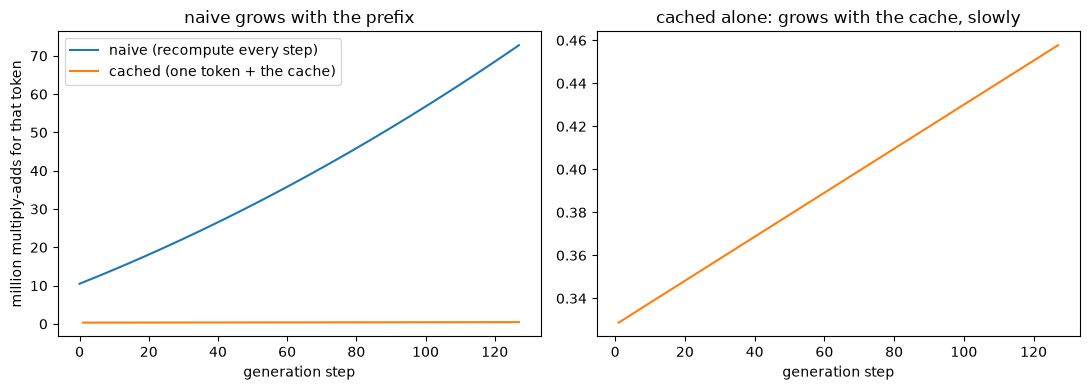

each cached step costs 1,024 more multiply-adds than the one before (= 2 x heads x head_dim x layers = 1,024: one more key to score and read)
last step: naive 72.8M vs cached 0.46M multiply-adds (159x)


wall clock on this CPU: naive 0.70 s, cached 0.05 s


In [9]:
# kerncore's copy of the model counts multiply-adds per call, so the cost is exact and the same on any
# machine; the wall-clock totals below are from this machine and will differ on yours.
big_params = kv.random_params(vocab=256, d_model=128, n_heads=4, n_layers=4, seed=1)
counted = kv.TinyDecoder(big_params)
prompt = rng.integers(0, 256, 32)
N = 128

_, _, naive_c  = kv.generate_naive(counted, prompt, N)
_, _, cached_c = kv.generate_cached(counted, prompt, N)
naive_macs  = kv.per_step_costs(naive_c)          # one entry per generated token
cached_macs = kv.per_step_costs(cached_c)[1:]     # drop the prefill; decode steps only

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(naive_macs / 1e6, label="naive (recompute every step)")
ax1.plot(np.arange(1, N), cached_macs / 1e6, label="cached (one token + the cache)")
ax1.set_xlabel("generation step"); ax1.set_ylabel("million multiply-adds for that token")
ax1.set_title("naive grows with the prefix"); ax1.legend()
ax2.plot(np.arange(1, N), cached_macs / 1e6, color="C1")
ax2.set_xlabel("generation step"); ax2.set_title("cached alone: grows with the cache, slowly")
plt.tight_layout(); plt.show()

cfg = counted.cfg
print(f"each cached step costs {np.diff(cached_macs)[0]:,.0f} more multiply-adds than the one before "
      f"(= 2 x heads x head_dim x layers = {2 * cfg['n_heads'] * cfg['head_dim'] * cfg['n_layers']:,}: one more key to score and read)")
print(f"last step: naive {naive_macs[-1] / 1e6:.1f}M vs cached {cached_macs[-1] / 1e6:.2f}M multiply-adds "
      f"({naive_macs[-1] / cached_macs[-1]:.0f}x)")

t0 = time.perf_counter(); generate_naive(MiniLM(big_params), prompt, N); t_naive = time.perf_counter() - t0
t0 = time.perf_counter(); generate_cached(MiniLM(big_params), prompt, N); t_cached = time.perf_counter() - t0
print(f"wall clock on this CPU: naive {t_naive:.2f} s, cached {t_cached:.2f} s")

## 4. Why serving is a memory problem

The cache trades compute for memory — and that memory is real. It grows with
**every token × every user × every layer**, and it sits in the same finite GPU HBM as
the weights. Plug real configs into the formula from the primer:

In [10]:
# The formula from the primer, in kerncore:  2 (K and V) x layers x kv_heads x head_dim x tokens x batch x bytes
# Llama 3 8B: 32 layers, 8 KV heads (grouped-query attention), head_dim 128, fp16 = 2 bytes.
per_tok = kv.kv_cache_bytes(32, 8, 128, seq_len=1)
print(f"per token              : {per_tok:,} bytes = {kv.fmt_bytes(per_tok)}")
for label, tokens, batch in (("1 user @ 8,192 tokens", 8192, 1),
                             ("1 user @ 128,000 tokens", 128_000, 1),
                             ("32 users @ 8,192 tokens", 8192, 32)):
    b = kv.kv_cache_bytes(32, 8, 128, tokens, batch=batch)
    print(f"{label:<23}: {kv.fmt_bytes(b)}")      # binary units, decimal GB in brackets

l3 = kv.MODELS["llama-3-8b"]
w = kv.weight_bytes(l3)
print(f"\nweights (fp16)         : {kv.fmt_bytes(w)}")
for dt in ("fp16", "fp8"):
    per = kv.kv_bytes_per_token(32, 8, 128, kv.DTYPE_BYTES[dt])
    n = kv.sessions_per_gpu(80e9, w, 8192, per)
    print(f"8K sessions in the rest of an 80 GB H100, {dt} cache: at most {n}")
print("(an upper bound: an engine also reserves memory for activations and its allocator)")

print("\nper token, by attention type (32 query heads, 32 layers, head_dim 128):")
for r in kv.kv_table(l3):
    heads = f"{r['kv_heads']} KV head" + ("s" if r['kv_heads'] > 1 else "")
    print(f"  {r['kind']} ({heads:>11}) {r['dtype']:<4}: {kv.fmt_bytes(r['per_layer']):>8} per layer, "
          f"{kv.fmt_bytes(r['per_token']):>9} per token")

_, cache = model.forward(rng.integers(0, 256, 10))                  # the tiny model above, 10 tokens
print(f"\nthe tiny model's real cache for 10 tokens: {sum(k.nbytes + v.nbytes for k, v in cache):,} bytes;"
      f" the formula (float64 = 8 bytes): {kv.kv_cache_bytes(4, 4, 32, 10, bytes_per=8):,}")

per token              : 131,072 bytes = 128 KiB
1 user @ 8,192 tokens  : 1.00 GiB (1.07 GB)
1 user @ 128,000 tokens: 15.62 GiB (16.78 GB)
32 users @ 8,192 tokens: 32.00 GiB (34.36 GB)

weights (fp16)         : 14.96 GiB (16.06 GB)
8K sessions in the rest of an 80 GB H100, fp16 cache: at most 59
8K sessions in the rest of an 80 GB H100, fp8 cache: at most 119
(an upper bound: an engine also reserves memory for activations and its allocator)

per token, by attention type (32 query heads, 32 layers, head_dim 128):
  MHA (32 KV heads) fp16:   16 KiB per layer,   512 KiB per token
  MHA (32 KV heads) fp8 :    8 KiB per layer,   256 KiB per token
  GQA ( 8 KV heads) fp16:    4 KiB per layer,   128 KiB per token
  GQA ( 8 KV heads) fp8 :    2 KiB per layer,    64 KiB per token
  MQA (  1 KV head) fp16: 0.50 KiB per layer,    16 KiB per token
  MQA (  1 KV head) fp8 : 0.25 KiB per layer,     8 KiB per token

the tiny model's real cache for 10 tokens: 81,920 bytes; the formula (float64 = 8 byt

## Optional: the same check in PyTorch

Skip this unless you have torch installed. It builds the same model from the same float64 weights in torch ops,
decodes the last prompt token from a torch cache, and compares with the numpy model's full forward pass.

In [11]:
# OPTIONAL comparison with PyTorch. Nothing above needs torch; this cell skips itself without it.
try:
    import torch
except ImportError:
    torch = None
    print("torch is not installed: comparison skipped (optional; everything above ran on numpy)")

if torch is not None:
    T = lambda a: torch.from_numpy(np.asarray(a, dtype=np.float64))

    def torch_forward(p, idx, caches=None):
        """The same MiniLM in torch ops, same float64 weights."""
        H = p["n_heads"]
        past = 0 if caches is None else caches[0][0].shape[1]
        x = T(p["emb"])[torch.as_tensor(idx)] + T(p["pos"])[past:past + len(idx)]
        new = []
        for i, lp in enumerate(p["layers"]):
            n, C = x.shape
            sp = lambda t: t.view(n, H, C // H).transpose(0, 1)
            q, k, v = sp(x @ T(lp["wq"])), sp(x @ T(lp["wk"])), sp(x @ T(lp["wv"]))
            if caches is not None:
                k, v = torch.cat([caches[i][0], k], 1), torch.cat([caches[i][1], v], 1)
            att = q @ k.transpose(-2, -1) / math.sqrt(C // H)
            mask = torch.arange(k.shape[1])[None, :] > torch.arange(past, past + n)[:, None]
            att = att.masked_fill(mask, float("-inf")).softmax(-1)
            x = x + (att @ v).transpose(0, 1).reshape(n, C) @ T(lp["wo"])
            new.append((k, v))
        return x @ T(p["head"]), new

    ids = rng.integers(0, 256, 16)
    with torch.no_grad():
        _, caches = torch_forward(params, ids[:15])            # prefill 15 tokens in torch
        step, _ = torch_forward(params, ids[15:], caches)      # decode the 16th from the torch cache
    ref, _ = model.forward(ids)                                # numpy, no cache
    print("torch", torch.__version__, "| cached torch step vs numpy full forward, max diff:",
          f"{np.abs(step.numpy()[-1] - ref[-1]).max():.1e}")

torch is not installed: comparison skipped (optional; everything above ran on numpy)


## Recap

- K and V for past tokens never change, so we store them instead of recomputing — that
  is the whole cache (`np.concatenate` along the time axis).
- Correct caching is **behaviour-preserving**: identical tokens and logits, linear instead of
  quadratic work.
- The saving turns generation into a **memory-bandwidth** job: each decode step must read
  the weights *and* the whole cache from HBM.
- Cache size scales with tokens, users, and layers — so context length and batch size are
  ultimately **memory** questions, which is exactly what GQA, quantization, and
  PagedAttention attack.

Now open **02** and rebuild the cache logic yourself.